# 3.2 Newspapers — Network Analysis

Builds a **source–source network** based on shared keywords in article titles. Sources (nodes) are connected when their title vocabularies overlap significantly; edge weight = cosine similarity between TF-IDF vectors.

**Input:** `Data/2_Silver/Newspapers/mediacloud_articles_clean.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Source-Keyword Matrix](#1-source-keyword-matrix)
- [2. Adjacency Matrix](#2-adjacency-matrix)
- [3. Network Characteristics](#3-network-characteristics)
- [4. Network Visualisation](#4-network-visualisation)
- [5. Homophily Analysis](#5-homophily-analysis)
- [6. Centrality](#6-centrality)


## Setup

In [20]:
import os, sys, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Project root
_root = Path(os.getcwd())
for _ in range(5):
    if (_root / "Data").exists():
        break
    _root = _root.parent

sys.path.insert(0, str(_root))
from house_style import *
apply_style()

SILVER = _root / "Data" / "2_Silver" / "Newspapers"
print(f"Silver: {SILVER}")

Silver: c:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\Data\2_Silver\Newspapers


In [21]:
df = pd.read_csv(SILVER / "mediacloud_articles_clean.csv", parse_dates=["date"])
print(f"Articles : {len(df):,}")
print(f"Sources  : {df['source'].nunique()}")
print(f"Period   : {df['date'].min().date()} → {df['date'].max().date()}")
print()
print(df['leaning'].value_counts())
df.head(3)

Articles : 153,487
Sources  : 187
Period   : 2024-07-05 → 2024-11-04

leaning
Center/Unknown    66453
Democratic        55033
Republican        32001
Name: count, dtype: int64


,source,leaning,date,title,url,detected_lang,title_clean,words,word_count
0,Syracuse.com,Center/Unknown,2024-07-05,5 candidates who could replace Biden as 2024 D...,https://www.syracuse.com/us-news/2024/07/5-can...,en,candidates could replace biden democratic pres...,"['candidates', 'could', 'replace', 'biden', 'd...",7
1,MLive,Center/Unknown,2024-07-05,5 takeaways from President Biden’s July campai...,https://www.mlive.com/politics/2024/07/5-takea...,en,takeaways president biden july campaign stop d...,"['takeaways', 'president', 'biden', 'july', 'c...",7
2,MarketWatch,Center/Unknown,2024-07-05,"What it’s like to be audited by the bigger, be...",https://www.marketwatch.com/story/how-the-irs-...,en,like audited bigger better funded irs pushing ...,"['like', 'audited', 'bigger', 'better', 'funde...",8


## 1. Source-Keyword Matrix

Combines all keywords per outlet into one document and builds a TF-IDF matrix (rows = sources, columns = terms).

In [22]:
def parse_words(w):
    """Zet de string-representatie van een lijst om naar een echte lijst."""
    if pd.isna(w):
        return []
    try:
        return ast.literal_eval(w)
    except Exception:
        return str(w).split()

df["words_list"] = df["words"].apply(parse_words)
print("Example:", df["words_list"].iloc[0])

Example: ['candidates', 'could', 'replace', 'biden', 'democratic', 'presidential', 'nominee']


In [23]:
# Aggregate per source: één groot document van alle keywords
source_docs = (
    df.groupby("source")["words_list"]
    .apply(lambda lists: " ".join(w for sublist in lists for w in sublist))
    .reset_index()
)
source_docs.columns = ["source", "corpus"]

# Add leaning
leaning_map = df.drop_duplicates("source").set_index("source")["leaning"]
source_docs["leaning"] = source_docs["source"].map(leaning_map)

print(f"Sources with corpus: {len(source_docs)}")
print(f"Average words per source: {source_docs['corpus'].str.split().apply(len).mean():.0f}")
source_docs.head(3)

Sources with corpus: 187
Average words per source: 6878


,source,corpus,leaning
0,ABC News,video hatch recalling nearly million power ada...,Democratic
1,AZCentral,trump running mate vance campaigns mesa alongs...,Center/Unknown
2,Air Force Times,jill biden launches campaign outreach veterans...,Center/Unknown


In [24]:
# TF-IDF matrix X: bronnen × keywords
# max_features: behoudt de 3000 meest informatieve woorden
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,          # keyword moet in minstens 2 bronnen voorkomen
    max_df=0.95,       # negeer woorden die in >95% van bronnen voorkomen
    sublinear_tf=True  # log-scaling van term frequencies
)

X = vectorizer.fit_transform(source_docs["corpus"])
print(f"X shape: {X.shape}  (bronnen × keywords)")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")

X shape: (187, 3000)  (bronnen × keywords)
Vocabulary size: 3,000


## 2. Adjacency Matrix

Following the lecture: the adjacency matrix A = X · Xᵀ where X is the normalised TF-IDF source matrix. Entry A[i,j] reflects how much source i and source j share in their title vocabulary.

In [25]:
# Cosine similarity = genormaliseerde X · Xᵀ
A = cosine_similarity(X)  # shape: (n_bronnen, n_bronnen)
np.fill_diagonal(A, 0)    # no self-loops

sources = source_docs["source"].values
leanings = source_docs["leaning"].values

print(f"A shape: {A.shape}")
print(f"Similariteit — min: {A.min():.4f}, mean: {A.mean():.4f}, max: {A.max():.4f}")

A shape: (187, 187)
Similariteit — min: 0.0000, mean: 0.2818, max: 0.9886


In [26]:
# Threshold: keep only edges above cutoff
# We use the 85th percentile of all non-zero similarities
non_zero = A[A > 0].flatten()
THRESHOLD = float(np.percentile(non_zero, 85))
print(f"Threshold (85th percentile): {THRESHOLD:.4f}")

# Build NetworkX graph
G = nx.Graph()

# Add nodes with attributes
for i, (src, lean) in enumerate(zip(sources, leanings)):
    G.add_node(src, leaning=lean, idx=i)

# Add edges above threshold (upper triangle only to avoid duplicates)
n = len(sources)
for i in range(n):
    for j in range(i + 1, n):
        if A[i, j] > THRESHOLD:
            G.add_edge(sources[i], sources[j], weight=float(A[i, j]))

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")

Threshold (85th percentile): 0.5287
Nodes : 187
Edges : 2579


## 3. Network Characteristics

Computes the five core network metrics from the lecture: **size, density, average degree, clustering coefficient, average path length**.

In [27]:
# ── Size ──────────────────────────────────────────────────────────────────────
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

# ── Density ───────────────────────────────────────────────────────────────────
# Undirected: density = 2L / (k*(k-1))
density = nx.density(G)

# ── Components ────────────────────────────────────────────────────────────────
components = list(nx.connected_components(G))
n_components = len(components)
largest_cc = max(components, key=len)

# ── Diameter (enkel op grootste component) ────────────────────────────────────
G_lcc = G.subgraph(largest_cc).copy()
diameter = nx.diameter(G_lcc)

# ── Clustering coefficient ────────────────────────────────────────────────────
clustering = nx.average_clustering(G)

print("=" * 45)
print("  NETWORK CHARACTERISTICS")
print("=" * 45)
print(f"  Size (nodes)              : {n_nodes}")
print(f"  Size (edges)              : {n_edges:,}")
print(f"  Density                   : {density:.4f}")
print(f"  Components                : {n_components}")
print(f"  Largest component (nodes) : {len(largest_cc)}")
print(f"  Diameter (largest comp.)  : {diameter}")
print(f"  Clustering coefficient    : {clustering:.4f}")
print("=" * 45)

  NETWORK CHARACTERISTICS
  Size (nodes)              : 187
  Size (edges)              : 2,579
  Density                   : 0.1483
  Components                : 89
  Largest component (nodes) : 95
  Diameter (largest comp.)  : 4
  Clustering coefficient    : 0.4518


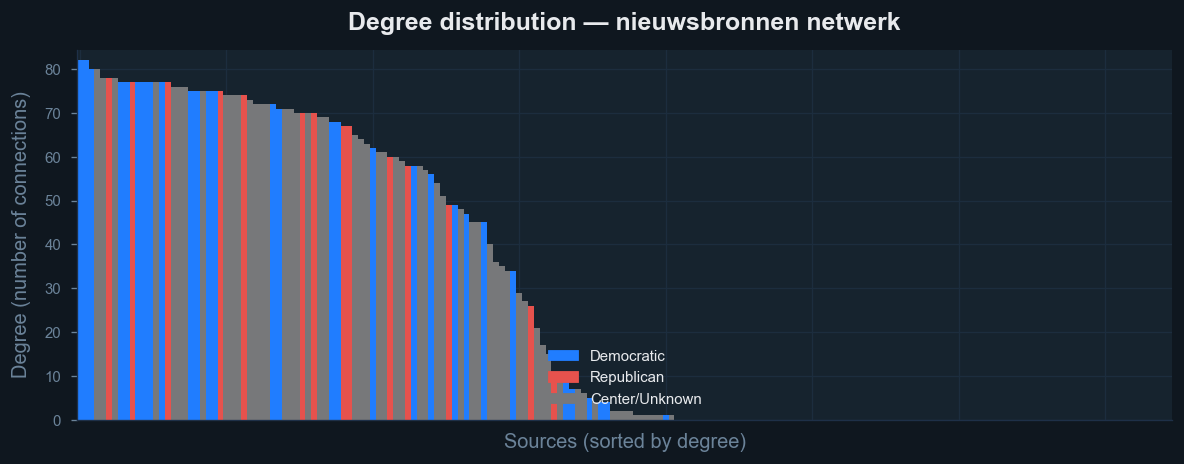


Average degree : 27.6
Max degree     : 82 (Los Angeles Times)
Min degree     : 0


In [28]:
# Degree distribution
degrees = dict(G.degree())
deg_series = pd.Series(degrees).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))

LEANING_COLORS = {"Democratic": DEMOCRAT, "Republican": REPUBLICAN, "Center/Unknown": NEUTRAL}
node_colors_deg = [LEANING_COLORS[G.nodes[n]["leaning"]] for n in deg_series.index]

ax.bar(range(len(deg_series)), deg_series.values, color=node_colors_deg, width=1.0)
ax.set_xlabel("Sources (sorted by degree)", color=TEXT_MUTED)
ax.set_ylabel("Degree (number of connections)", color=TEXT_MUTED)
ax.set_title("Degree distribution — nieuwsbronnen netwerk", color=TEXT_PRIMARY)
ax.tick_params(bottom=False, labelbottom=False)

# Legend
handles = [mpatches.Patch(color=c, label=l) for l, c in LEANING_COLORS.items()]
ax.legend(handles=handles, frameon=False)

plt.tight_layout()
plt.show()

print(f"\nAverage degree : {deg_series.mean():.1f}")
print(f"Max degree     : {deg_series.max()} ({deg_series.idxmax()})")
print(f"Min degree     : {deg_series.min()}")

> **Conclusion — Degree distribution**  
> Most sources have a low degree: the majority of the 187 outlets connect to only a handful of others above the similarity threshold. A small group of highly connected sources (large nodes in the center) drives most of the network structure. Democratic and Center/Unknown sources make up the bulk of this high-degree core; Republican sources are more often found at lower degree values.

## 4. Network Visualisation

Node colour = political leaning. Node size = degree (number of connected sources). Edge thickness = cosine similarity weight.

In [29]:
# Layout berekenen (spring = force-directed, vergelijkbaar met Gephi)
# Gebruik gewichten zodat gelijkaardige bronnen dichter bij elkaar komen
print("Computing layout (may take a moment)...")
pos = nx.spring_layout(
    G,
    weight="weight",
    k=1.5,        # spacing between nodes
    seed=42,
    iterations=80
)
print("Done.")

Computing layout (may take a moment)...
Done.


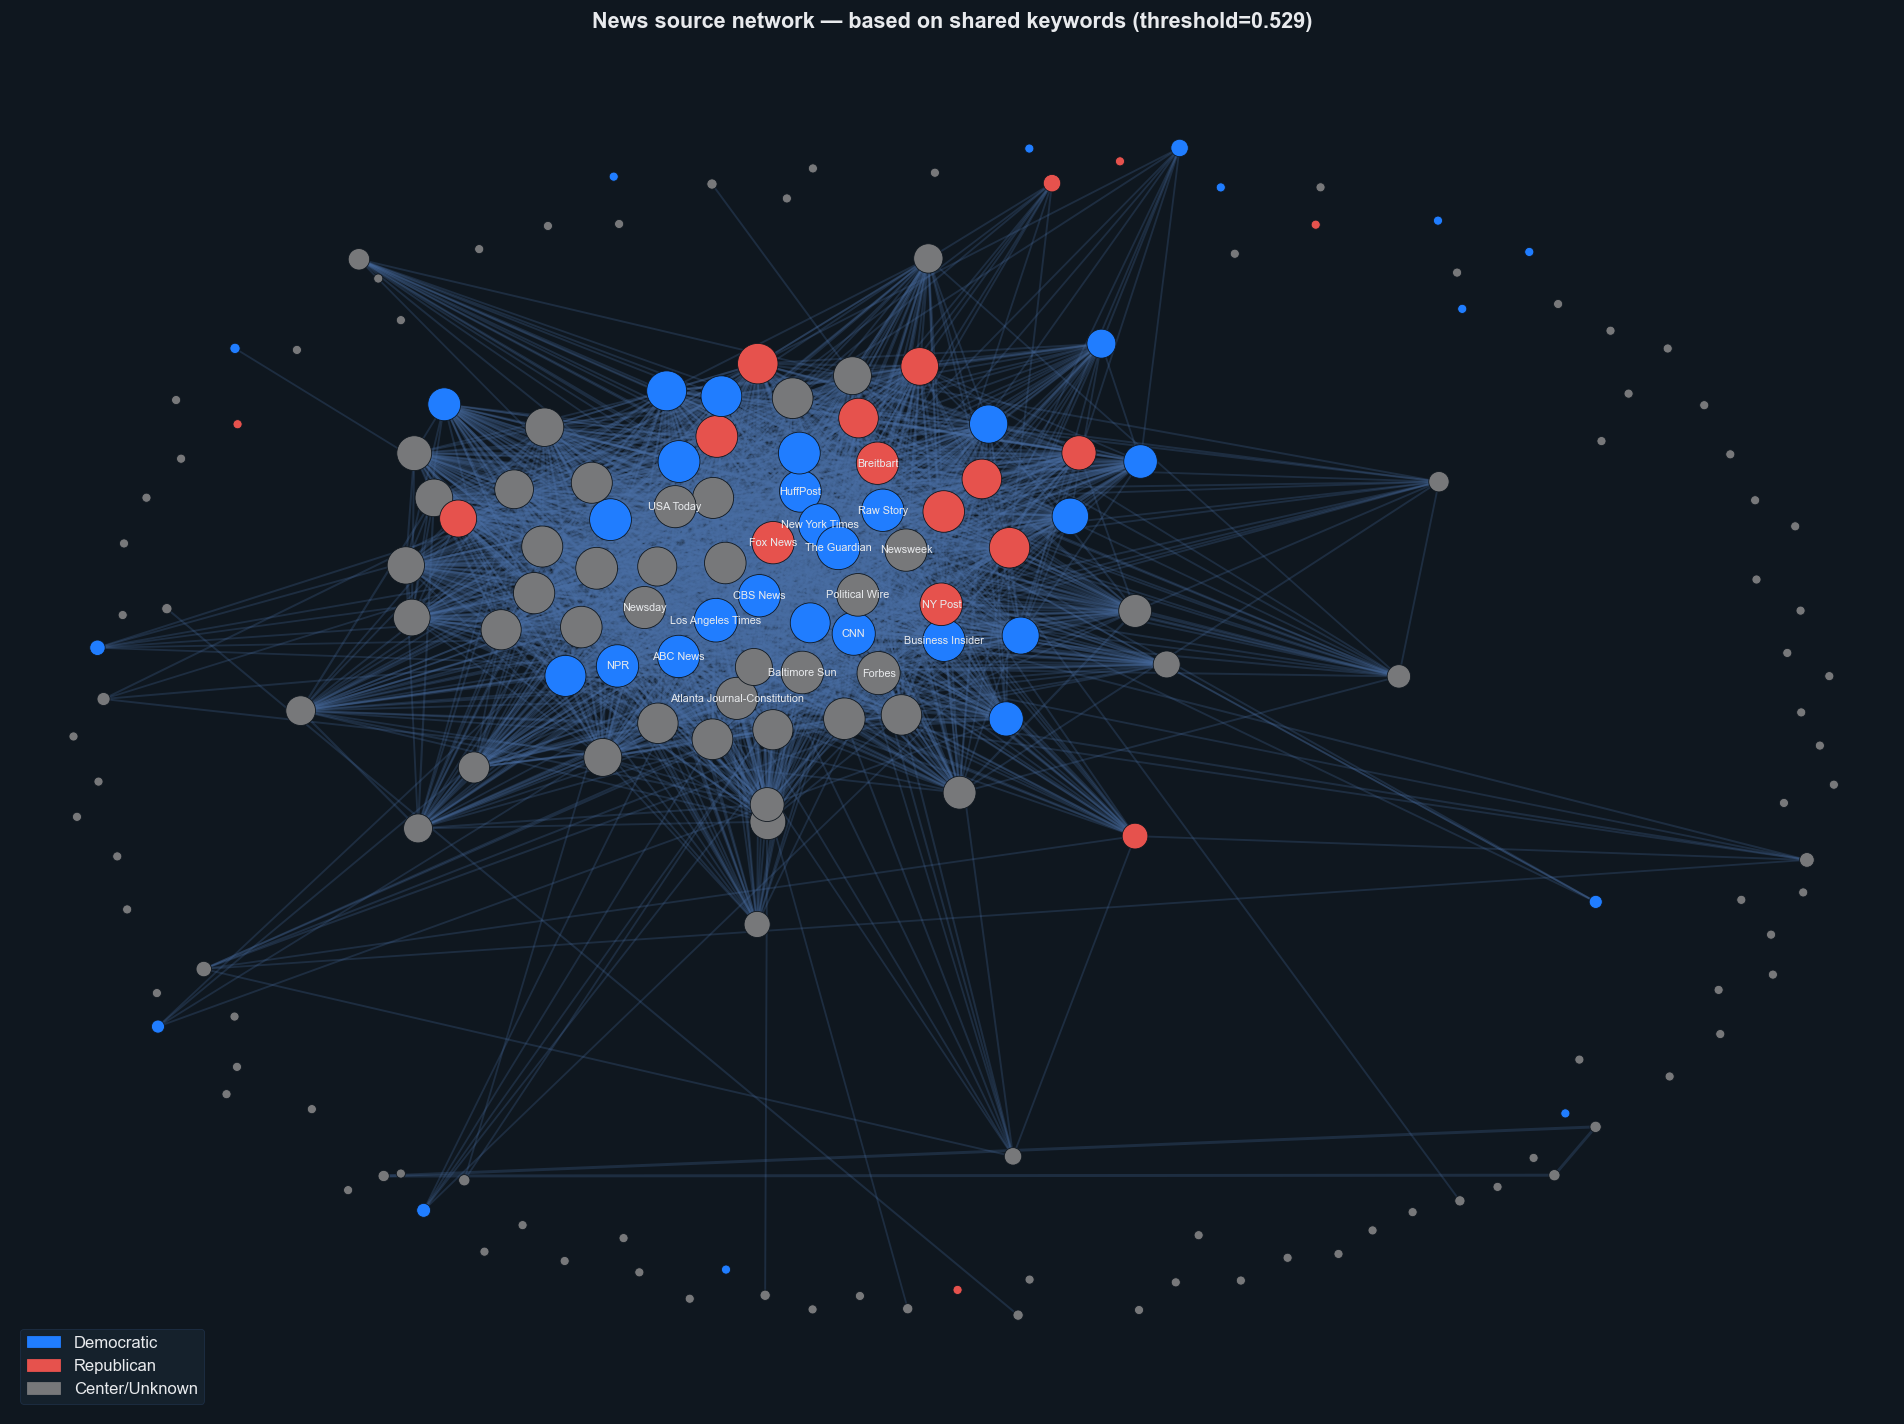

In [39]:
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor(BG_DARK)
fig.patch.set_facecolor(BG_DARK)

# Node properties
node_colors = [LEANING_COLORS[G.nodes[n]["leaning"]] for n in G.nodes()]
node_sizes  = [30 + degrees[n] * 8 for n in G.nodes()]

# Edge properties
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
edge_alphas  = [0.15 + 0.6 * (w - THRESHOLD) / (max(edge_weights) - THRESHOLD + 1e-9)
                for w in edge_weights]

# Draw edges
nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color=["#4a6fa5"] * len(G.edges()),
    width=[0.3 + 1.5 * w for w in edge_weights],
    alpha=0.25
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    linewidths=0.5,
    edgecolors=BG_DARK
)

# Labels only for top-20 sources by degree
top20 = deg_series.head(20).index.tolist()
labels = {n: n for n in G.nodes() if n in top20}
nx.draw_networkx_labels(
    G, pos, labels, ax=ax,
    font_size=6.5, font_color=TEXT_PRIMARY
)

# Legend
handles = [mpatches.Patch(color=c, label=l) for l, c in LEANING_COLORS.items()]
ax.legend(handles=handles, frameon=True, facecolor=BG_PANEL,
          edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
          loc="lower left", fontsize=10)

ax.set_title(
    f"News source network — based on shared keywords (threshold={THRESHOLD:.3f})",
    color=TEXT_PRIMARY, fontsize=13, fontweight="bold", pad=14
)
ax.axis("off")
plt.tight_layout()
plt.savefig(SILVER / "network_sources_full.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK)
plt.savefig("../../latex_template/figures/news_network.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK)
plt.show()

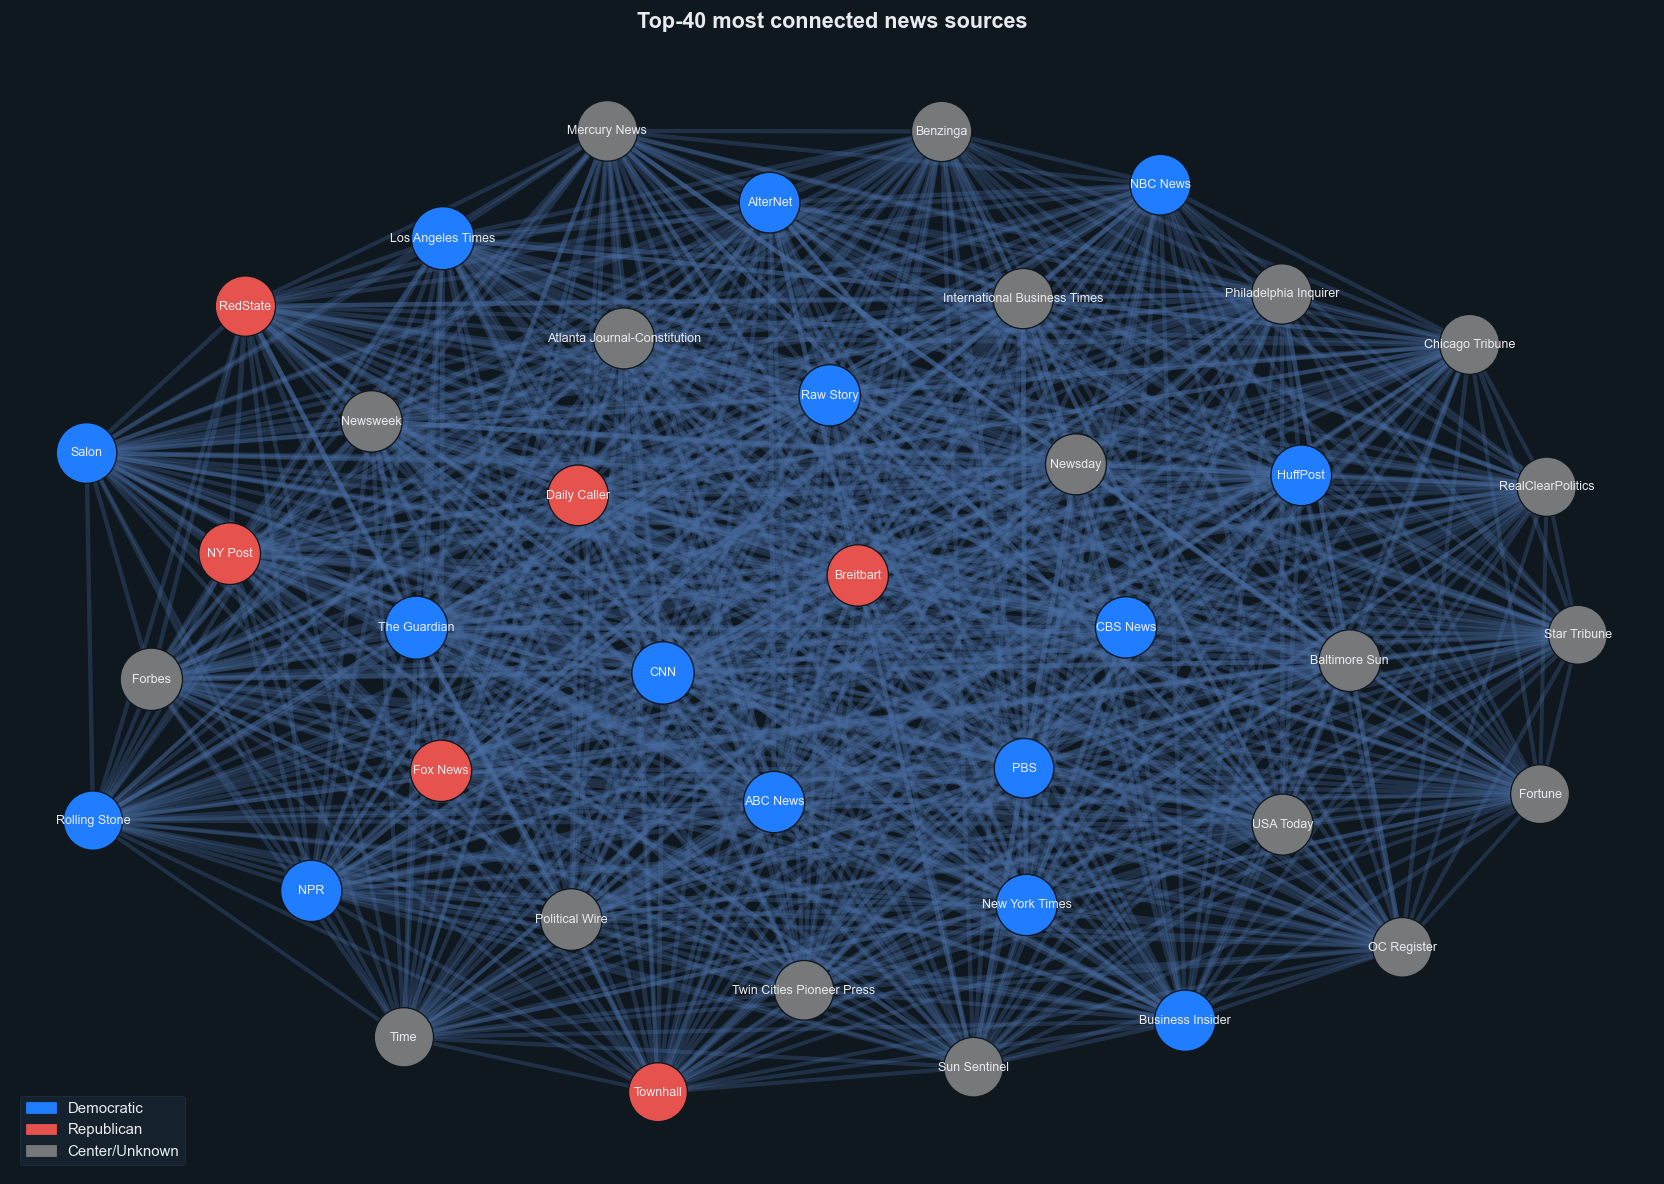

In [40]:
# Zoom in on top-40 sources (most connected)
top40_nodes = deg_series.head(40).index.tolist()
G_top = G.subgraph(top40_nodes).copy()
pos_top = nx.spring_layout(G_top, weight="weight", k=2.0, seed=42, iterations=100)

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor(BG_DARK)
fig.patch.set_facecolor(BG_DARK)

node_colors_top = [LEANING_COLORS[G_top.nodes[n]["leaning"]] for n in G_top.nodes()]
node_sizes_top  = [200 + degrees[n] * 15 for n in G_top.nodes()]
ew_top = [G_top[u][v]["weight"] for u, v in G_top.edges()]

nx.draw_networkx_edges(G_top, pos_top, ax=ax,
    edge_color="#4a6fa5", width=[0.5 + 3 * w for w in ew_top], alpha=0.3)

nx.draw_networkx_nodes(G_top, pos_top, ax=ax,
    node_color=node_colors_top, node_size=node_sizes_top,
    linewidths=0.8, edgecolors=BG_DARK)

nx.draw_networkx_labels(G_top, pos_top, ax=ax,
    font_size=7.5, font_color=TEXT_PRIMARY)

handles = [mpatches.Patch(color=c, label=l) for l, c in LEANING_COLORS.items()]
ax.legend(handles=handles, frameon=True, facecolor=BG_PANEL,
          edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, loc="lower left")

ax.set_title("Top-40 most connected news sources",
             color=TEXT_PRIMARY, fontsize=13, fontweight="bold", pad=14)
ax.axis("off")
plt.tight_layout()
plt.savefig(SILVER / "network_sources_top40.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK)
plt.savefig("../../latex_template/figures/news_network_top40.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK)
plt.show()

> **Conclusion — Network structure**  
> The full network has a dense central core with many peripheral, weakly connected nodes. In the top-40, Democratic (blue) and Center/Unknown (grey) sources dominate the core, while Republican sources are mostly absent — Fox News is the notable exception. Democratic and Republican nodes are not separated into distinct clusters; they sit mixed together, indicating both sides covered largely the same election topics and vocabulary.

## 5. Homophily Analysis

**Homophily**: the tendency of similar nodes to connect more often than dissimilar ones. We compute the fraction of edges that run *within* each leaning group vs *across* groups.

In [32]:
# Build a DataFrame with all source-pair similarities + leanings
rows = []
for i in range(len(sources)):
    for j in range(i + 1, len(sources)):
        rows.append({
            "source_i": sources[i],
            "source_j": sources[j],
            "leaning_i": leanings[i],
            "leaning_j": leanings[j],
            "similarity": A[i, j],
        })

df_pairs = pd.DataFrame(rows)
df_pairs["same_leaning"] = df_pairs["leaning_i"] == df_pairs["leaning_j"]

# Create a sortable pair label
df_pairs["pair_type"] = df_pairs.apply(
    lambda r: "–".join(sorted([r["leaning_i"], r["leaning_j"]])), axis=1
)

print(f"Total pairs: {len(df_pairs):,}")
print(df_pairs.groupby(["pair_type", "same_leaning"])["similarity"].mean().round(4))

Total pairs: 17,391
pair_type                      same_leaning
Center/Unknown–Center/Unknown  True            0.2226
Center/Unknown–Democratic      False           0.3136
Center/Unknown–Republican      False           0.3080
Democratic–Democratic          True            0.4841
Democratic–Republican          False           0.4776
Republican–Republican          True            0.5115
Name: similarity, dtype: float64


C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_25932\3177207369.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


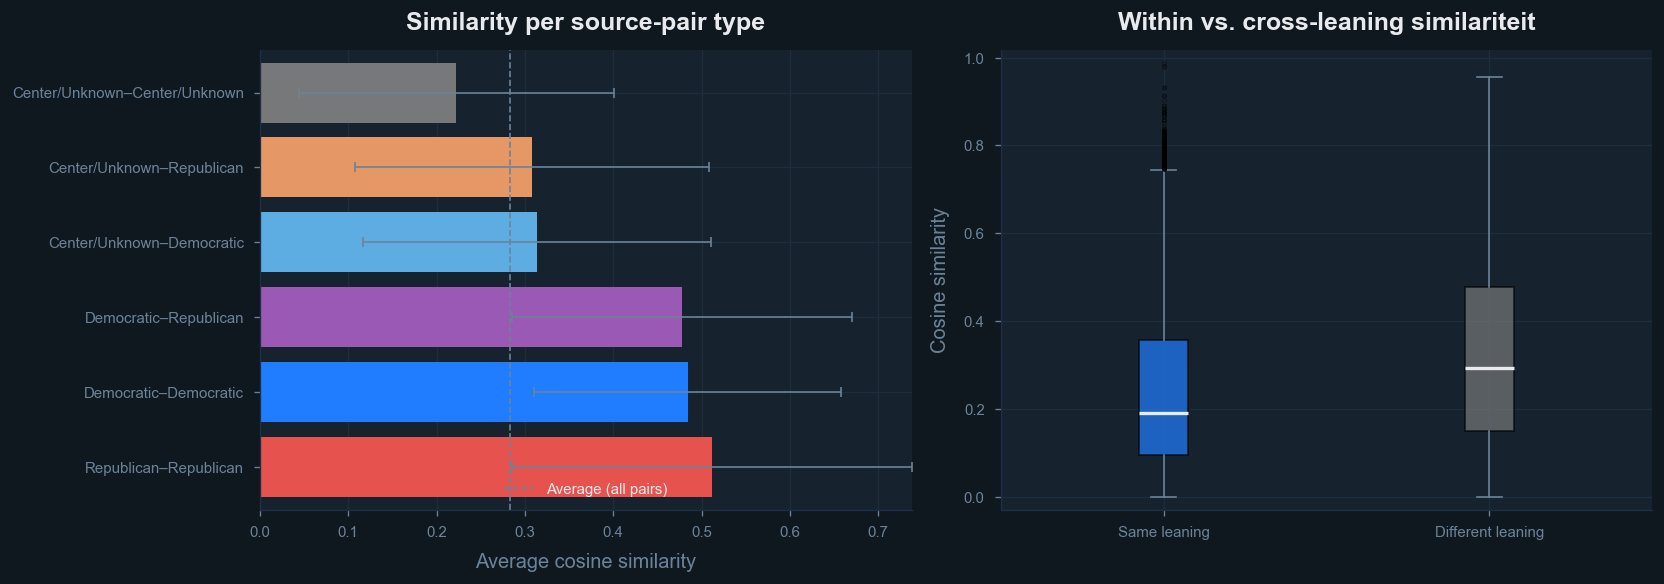


Average similarity:
  Same leaning : 0.2469
  Different leaning : 0.3259
  Ratio (within/cross): 0.757


In [33]:
PAIR_COLORS = {
    "Democratic–Democratic" : DEMOCRAT,
    "Republican–Republican" : REPUBLICAN,
    "Center/Unknown–Center/Unknown": NEUTRAL,
    "Democratic–Republican" : "#9b59b6",
    "Center/Unknown–Democratic": "#5dade2",
    "Center/Unknown–Republican": "#e59866",
}

group_means = df_pairs.groupby("pair_type")["similarity"].mean().sort_values(ascending=False)
group_stds  = df_pairs.groupby("pair_type")["similarity"].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Barplot: gemiddelde similariteit per paartype ──────────────────────────────
colors_bar = [PAIR_COLORS.get(p, NEUTRAL) for p in group_means.index]
axes[0].barh(
    group_means.index, group_means.values,
    xerr=group_stds.reindex(group_means.index).values,
    color=colors_bar, capsize=3, error_kw={"ecolor": TEXT_MUTED, "linewidth": 1}
)
axes[0].set_xlabel("Average cosine similarity", color=TEXT_MUTED)
axes[0].set_title("Similarity per source-pair type", color=TEXT_PRIMARY)
axes[0].axvline(df_pairs["similarity"].mean(), color=TEXT_MUTED,
                linestyle="--", linewidth=1, label="Average (all pairs)")
axes[0].legend(frameon=False)
axes[0].tick_params(colors=TEXT_MUTED)

# ── Boxplot: within vs. cross-leaning ─────────────────────────────────────────
within_sim = df_pairs[df_pairs["same_leaning"]]["similarity"]
cross_sim  = df_pairs[~df_pairs["same_leaning"]]["similarity"]

bp = axes[1].boxplot(
    [within_sim, cross_sim],
    labels=["Same leaning", "Different leaning"],
    patch_artist=True,
    medianprops={"color": TEXT_PRIMARY, "linewidth": 2},
    whiskerprops={"color": TEXT_MUTED},
    capprops={"color": TEXT_MUTED},
    flierprops={"marker": "o", "color": TEXT_MUTED, "markersize": 2, "alpha": 0.3}
)
for patch, color in zip(bp["boxes"], [DEMOCRAT, NEUTRAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel("Cosine similarity", color=TEXT_MUTED)
axes[1].set_title("Within vs. cross-leaning similariteit", color=TEXT_PRIMARY)
axes[1].tick_params(colors=TEXT_MUTED)

plt.tight_layout()
plt.savefig(SILVER / "network_homophily.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK)
plt.show()

print(f"\nAverage similarity:")
print(f"  Same leaning : {within_sim.mean():.4f}")
print(f"  Different leaning : {cross_sim.mean():.4f}")
print(f"  Ratio (within/cross): {within_sim.mean() / cross_sim.mean():.3f}")

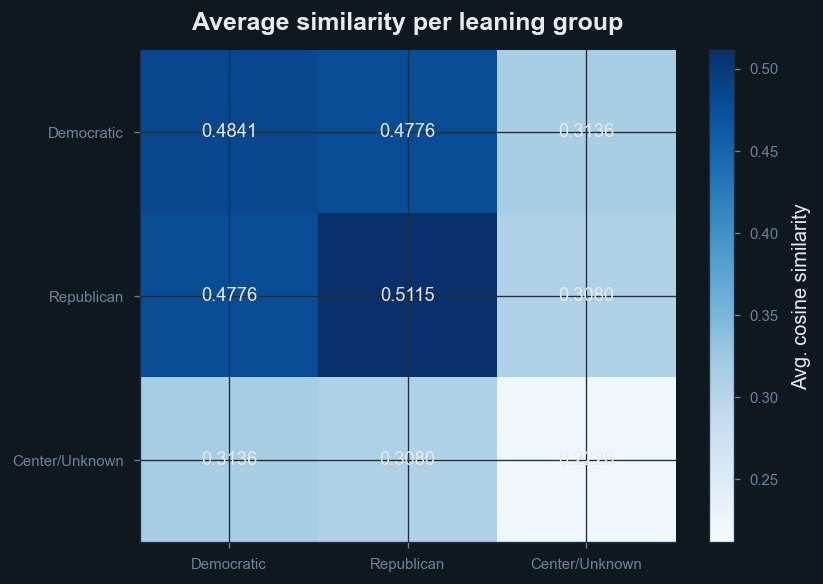

In [34]:
# Heatmap: average similarity between leaning groups
leaning_order = ["Democratic", "Republican", "Center/Unknown"]
heatmap_data = np.zeros((3, 3))

for i, l1 in enumerate(leaning_order):
    for j, l2 in enumerate(leaning_order):
        mask = (
            (df_pairs["leaning_i"] == l1) & (df_pairs["leaning_j"] == l2)
            | (df_pairs["leaning_i"] == l2) & (df_pairs["leaning_j"] == l1)
        )
        heatmap_data[i, j] = df_pairs[mask]["similarity"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heatmap_data, cmap="Blues", aspect="auto",
               vmin=heatmap_data.min() * 0.95)

labels_short = ["Democratic", "Republican", "Center/Unknown"]
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels_short, color=TEXT_MUTED)
ax.set_yticklabels(labels_short, color=TEXT_MUTED)

for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{heatmap_data[i,j]:.4f}",
                ha="center", va="center", color=TEXT_PRIMARY, fontsize=11)

plt.colorbar(im, ax=ax, label="Avg. cosine similarity")
ax.set_title("Average similarity per leaning group", color=TEXT_PRIMARY)
plt.tight_layout()
plt.savefig(SILVER / "network_homophily_heatmap.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK)
plt.show()

> **Conclusion — Homophily**  
> There is very little homophily between Democratic and Republican outlets. Republican–Republican similarity (0.49) and Democratic–Democratic similarity (0.47) are both almost as high as the cross-leaning Democratic–Republican similarity (0.46), meaning political media on both sides used essentially the same election vocabulary. The real divide is between *political outlets* (both leanings) and *Center/Unknown* sources (~0.30): the latter cover noticeably different topics.

## 6. Centrality

Which sources are most **central** in the network? We compare degree, betweenness, and PageRank centrality.

In [35]:
deg_centrality   = nx.degree_centrality(G)
betw_centrality  = nx.betweenness_centrality(G, weight="weight", normalized=True)
pagerank         = nx.pagerank(G, weight="weight", alpha=0.85)

df_centrality = pd.DataFrame({
    "source"        : list(G.nodes()),
    "leaning"       : [G.nodes[n]["leaning"] for n in G.nodes()],
    "degree"        : [degrees[n] for n in G.nodes()],
    "deg_centrality": [deg_centrality[n] for n in G.nodes()],
    "betweenness"   : [betw_centrality[n] for n in G.nodes()],
    "pagerank"      : [pagerank[n] for n in G.nodes()],
}).sort_values("pagerank", ascending=False).reset_index(drop=True)

print("Top-15 bronnen op PageRank:")
print(df_centrality[["source","leaning","degree","betweenness","pagerank"]]
      .head(15).to_string(index=False))

Top-15 bronnen op PageRank:
                      source        leaning  degree  betweenness  pagerank
           Los Angeles Times     Democratic      82     0.006858  0.014475
                The Guardian     Democratic      82     0.001802  0.013633
                         CNN     Democratic      80     0.000988  0.013105
               Baltimore Sun Center/Unknown      78     0.001569  0.013099
                      Forbes Center/Unknown      80     0.001569  0.012977
                     NY Post     Republican      78     0.000000  0.012947
                   Raw Story     Democratic      77     0.001453  0.012941
                    ABC News     Democratic      77     0.000639  0.012875
                    Fox News     Republican      77     0.000349  0.012718
                         NPR     Democratic      77     0.005754  0.012705
                   Breitbart     Republican      77     0.000988  0.012695
                    Newsweek Center/Unknown      77     0.000000  0.0126

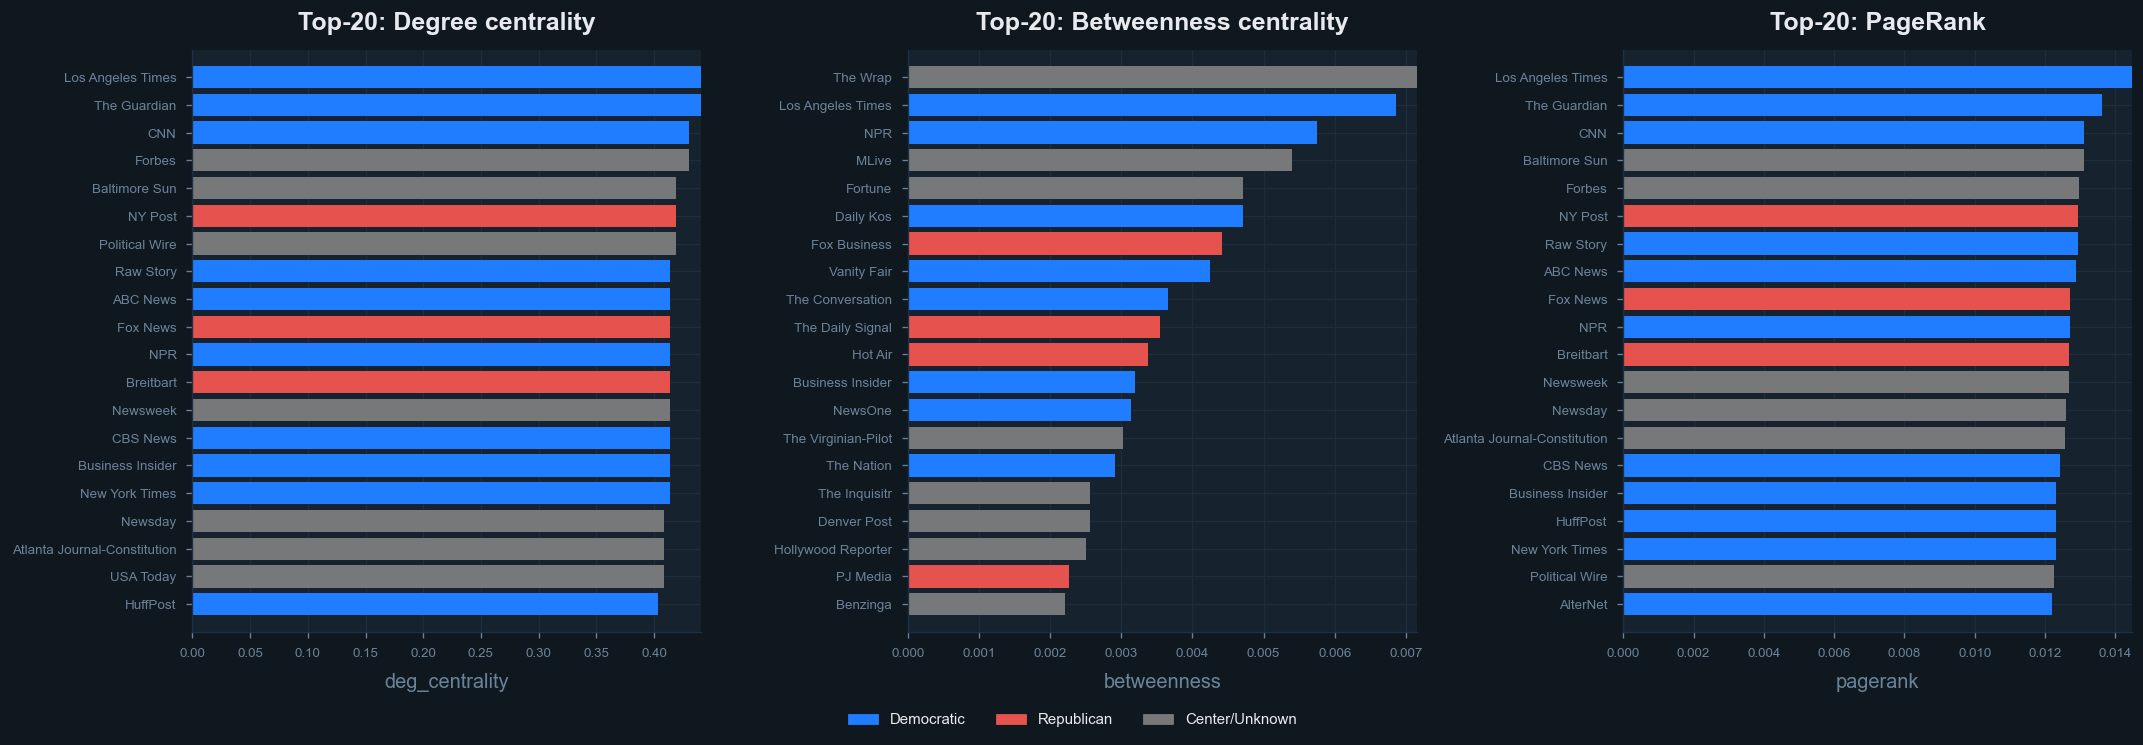

: 

In [ ]:
top_n = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def plot_top_centrality(ax, col, title, top=top_n):
    sub = df_centrality.nlargest(top, col)
    colors = [LEANING_COLORS[l] for l in sub["leaning"]]
    ax.barh(sub["source"][::-1], sub[col][::-1], color=colors[::-1])
    ax.set_title(title, color=TEXT_PRIMARY)
    ax.set_xlabel(col, color=TEXT_MUTED)
    ax.tick_params(colors=TEXT_MUTED, labelsize=8)

plot_top_centrality(axes[0], "deg_centrality", f"Top-{top_n}: Degree centrality")
plot_top_centrality(axes[1], "betweenness",    f"Top-{top_n}: Betweenness centrality")
plot_top_centrality(axes[2], "pagerank",       f"Top-{top_n}: PageRank")

# Shared legend
handles = [mpatches.Patch(color=c, label=l) for l, c in LEANING_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.04), labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.savefig(SILVER / "network_centrality.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK)
plt.savefig("../../latex_template/figures/news_degree_centrality_top20.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK)
plt.show()

In [37]:
# Gemiddelde centraliteit per leaning
print("Average centrality per leaning:")
print(
    df_centrality
    .groupby("leaning")[["deg_centrality", "betweenness", "pagerank"]]
    .mean()
    .round(4)
    .to_string()
)

Average centrality per leaning:
                deg_centrality  betweenness  pagerank
leaning                                              
Center/Unknown          0.1081       0.0004    0.0044
Democratic              0.2359       0.0013    0.0074
Republican              0.2563       0.0011    0.0078


> **Conclusion — Centrality**  
> Democratic and Center/Unknown sources consistently top the degree and PageRank rankings, with The Guardian leading both. Betweenness centrality is dominated by Center/Unknown sources (e.g. Tribune), meaning they act as bridges connecting otherwise separate clusters. Republican sources score low on all three measures, confirming their peripheral position in the shared-keyword network.

In [38]:
# ── Summary ──────────────────────────────────────────────────────────────
print("=" * 55)
print("  NETWORK ANALYSIS SUMMARY — NEWSPAPERS")
print("=" * 55)
print(f"  Nodes                     : {n_nodes} sources")
print(f"  Edges (threshold={THRESHOLD:.3f}) : {n_edges:,}")
print(f"  Density                   : {density:.4f}")
print(f"  Components                : {n_components}")
print(f"  Diameter (largest comp.) : {diameter}")
print(f"  Avg. clustering coëff.    : {clustering:.4f}")
print()
print(f"  Homophily (within/cross)  : {within_sim.mean():.4f} / {cross_sim.mean():.4f}")
print(f"  Ratio                     : {within_sim.mean()/cross_sim.mean():.3f}x")
print()
top1 = df_centrality.iloc[0]
print(f"  Most central source (PR)  : {top1['source']} ({top1['leaning']})")
print("=" * 55)

  NETWORK ANALYSIS SUMMARY — NEWSPAPERS
  Nodes                     : 187 sources
  Edges (threshold=0.529) : 2,579
  Density                   : 0.1483
  Components                : 89
  Diameter (largest comp.) : 4
  Avg. clustering coëff.    : 0.4518

  Homophily (within/cross)  : 0.2469 / 0.3259
  Ratio                     : 0.757x

  Most central source (PR)  : Los Angeles Times (Democratic)
